In [14]:
# import packages and load data in
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

year_and_month = ['202511','202512','202601', '202602', '202603', '202604', '202605']
CRMLSSold_data = pd.DataFrame()

for year_month in year_and_month:
    # PostalCode forced to str to prevent mixed-type warning
    data = pd.read_csv(f'data/CRMLSSold{year_month}.csv', dtype={'PostalCode': str})
    CRMLSSold_data = pd.concat([CRMLSSold_data, data], ignore_index=True)

# PropertyType filter
CRMLSSold_data = CRMLSSold_data[
    (CRMLSSold_data['PropertyType'] == 'Residential') &
    (CRMLSSold_data['PropertySubType'] == 'SingleFamilyResidence')
]

# PostalCode: extract valid 5-digit codes only
CRMLSSold_data['PostalCode'] = (
    CRMLSSold_data['PostalCode'].str.strip().str.extract(r'(\d{5})')[0]
)

# Latitude/Longitude: null out any coordinates outside California's bounding box
CA_LAT = (32.0, 42.5)
CA_LON = (-124.5, -114.0)
invalid_coords = (
    CRMLSSold_data['Latitude'].notna() & (
        ~CRMLSSold_data['Latitude'].between(*CA_LAT) |
        ~CRMLSSold_data['Longitude'].between(*CA_LON)
    )
)
n_invalid = invalid_coords.sum()
CRMLSSold_data.loc[invalid_coords, ['Latitude', 'Longitude']] = pd.NA
print(f"Nulled {n_invalid:,} out-of-bounds coordinates")
print(f"Loaded {len(CRMLSSold_data):,} rows")

/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_41178/1255940282.py:12: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(f'data/CRMLSSold{year_month}.csv', dtype={'PostalCode': str})


Nulled 28 out-of-bounds coordinates
Loaded 71,466 rows


In [15]:
# Remove duplicate listings and out-of-state listings

n = len(CRMLSSold_data)

# check missigness in ListingKet and StateOrProvince columns
print(f"Missing ListingKey: {CRMLSSold_data['ListingKey'].isnull().sum()}")
print(f"Missing StateOrProvince: {CRMLSSold_data['StateOrProvince'].isnull().sum()}")

# Drop duplicate listings — keep first occurrence by ListingKey
CRMLSSold_data = CRMLSSold_data.drop_duplicates(subset='ListingKey', keep='first')
print(f"After removing duplicates:        {len(CRMLSSold_data):,}  (-{n - len(CRMLSSold_data):,})")

# Remove out-of-state listings  keep only California
n = len(CRMLSSold_data)
# print the non ca listing
print("Non-California listings:")
print(CRMLSSold_data[CRMLSSold_data['StateOrProvince'] != 'CA'][['ListingKey', 'StateOrProvince']])
CRMLSSold_data = CRMLSSold_data[CRMLSSold_data['StateOrProvince'] == 'CA']
print(f"After removing out-of-state:      {len(CRMLSSold_data):,}  (-{n - len(CRMLSSold_data):,})")

CRMLSSold_data = CRMLSSold_data.reset_index(drop=True)
print(f"\nFinal row count: {len(CRMLSSold_data):,}")

Missing ListingKey: 0
Missing StateOrProvince: 0
After removing duplicates:        71,414  (-52)
Non-California listings:
        ListingKey StateOrProvince
111847  1152718643              AZ
After removing out-of-state:      71,413  (-1)

Final row count: 71,413


In [16]:
# Derive HasAssociationFee flag — captures presence of an HOA fee without
# guessing at the dollar amount (AssociationFee is ~30% missing and 0 is
# a valid "no HOA" value, so imputing the raw fee would be ambiguous)
CRMLSSold_data['HasAssociationFee'] = np.select(
    [CRMLSSold_data['AssociationFee'].isna(), CRMLSSold_data['AssociationFee'] > 0],
    ['Unknown', 'True'],
    default='False'
)
print(CRMLSSold_data['HasAssociationFee'].value_counts(dropna=False))

HasAssociationFee
False      32263
Unknown    20449
True       18701
Name: count, dtype: int64


In [17]:
# Features decided in 01_exploration.ipynb

# Target
target = ['ClosePrice']

# Core size/structure features
size_features = [
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'YearBuilt',
    'GarageSpaces',
    'LotSizeSquareFeet',
]

# Location features
location_features = [
    'CountyOrParish',
    'Latitude',
    'Longitude',
    'PostalCode',
]

# Amenity flags
amenity_features = [
    'PoolPrivateYN',
    'ViewYN',
    'FireplaceYN',
    'NewConstructionYN',
    'HasAssociationFee',
]

# All features (full set — for tree models and feature engineering)
all_features = size_features + location_features + amenity_features

# Baseline model features — excludes postal (high-cardinality); includes lat/long
baseline_features = size_features + ['CountyOrParish', 'Latitude', 'Longitude'] + amenity_features

# Numeric columns allowed to keep missing values here — median-imputed later
# via a pipeline step in the baseline model, not dropped
impute_later_cols = ['GarageSpaces', 'LotSizeSquareFeet']

print(f"All features ({len(all_features)}): {all_features}")
print(f"\nBaseline features ({len(baseline_features)}): {baseline_features}")

All features (15): ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'GarageSpaces', 'LotSizeSquareFeet', 'CountyOrParish', 'Latitude', 'Longitude', 'PostalCode', 'PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'NewConstructionYN', 'HasAssociationFee']

Baseline features (14): ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'GarageSpaces', 'LotSizeSquareFeet', 'CountyOrParish', 'Latitude', 'Longitude', 'PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'NewConstructionYN', 'HasAssociationFee']


In [18]:
# Fix data types for consistency

# Dates: parse string columns to datetime
date_cols = ['CloseDate']
for col in date_cols:
    CRMLSSold_data[col] = pd.to_datetime(CRMLSSold_data[col], errors='coerce')

# Integers stored as float (no decimals, but nullable so use Int64)
int_cols = ['BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt']
for col in int_cols:
    if col in CRMLSSold_data.columns:
        CRMLSSold_data[col] = CRMLSSold_data[col].astype('Int64')



print("Updated dtypes:")
print(CRMLSSold_data[date_cols + int_cols].dtypes)

Updated dtypes:
CloseDate                datetime64[us]
BedroomsTotal                     Int64
BathroomsTotalInteger             Int64
YearBuilt                         Int64
dtype: object


In [19]:
# table of missing percentage of each feature
all_cols = target + all_features
missing = CRMLSSold_data[all_cols].isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing.rename('% Missing').to_frame())

,% Missing
ViewYN,8.70
PoolPrivateYN,7.82
NewConstructionYN,7.55
GarageSpaces,3.85
LotSizeSquareFeet,1.72
FireplaceYN,0.09
YearBuilt,0.06
LivingArea,0.05
Latitude,0.05
Longitude,0.05


In [20]:
# Sanity filters and 1st/99th percentile boundary removal

n_start = len(CRMLSSold_data)
print(f"Start: {n_start:,}")

#  Hard filters: physically impossible or clearly bad values
n = len(CRMLSSold_data)
CRMLSSold_data = CRMLSSold_data[
    (CRMLSSold_data["ClosePrice"] > 0) &
    (CRMLSSold_data["LivingArea"] > 0) &
    (CRMLSSold_data["BedroomsTotal"] > 0) &
    (CRMLSSold_data["YearBuilt"].isna() | CRMLSSold_data["YearBuilt"].between(1800, 2026))
]
print(f"After hard filters:      {len(CRMLSSold_data):,}  (-{n - len(CRMLSSold_data):,})")

#  1st/99th percentile removal
# 99th percentile removal only for bedrooms and bathrooms due to the few outliers runing generalization
# Compute all bounds first on the same snapshot, then filter once.
price_low,  price_high  = CRMLSSold_data["ClosePrice"].quantile([0.01, 0.99])
living_low, living_high = CRMLSSold_data["LivingArea"].quantile([0.01, 0.99])
lot_low,    lot_high    = CRMLSSold_data["LotSizeSquareFeet"].quantile([0.01, 0.99])
bed_high                = CRMLSSold_data["BedroomsTotal"].quantile(0.99)
bath_high               = CRMLSSold_data["BathroomsTotalInteger"].quantile(0.99)

n = len(CRMLSSold_data)
CRMLSSold_data = CRMLSSold_data[
    CRMLSSold_data["ClosePrice"].between(price_low, price_high) &
    CRMLSSold_data["LivingArea"].between(living_low, living_high) &
    (CRMLSSold_data["LotSizeSquareFeet"].isna() | CRMLSSold_data["LotSizeSquareFeet"].between(lot_low, lot_high)) &
    (CRMLSSold_data["BedroomsTotal"] <= bed_high) &
    (CRMLSSold_data["BathroomsTotalInteger"].isna() | (CRMLSSold_data["BathroomsTotalInteger"] <= bath_high))
]
print(f"After percentile filter: {len(CRMLSSold_data):,}  (-{n - len(CRMLSSold_data):,})")

n_end = len(CRMLSSold_data)
print(f"{n_start:,}  ->  {n_end:,}  (-{n_start - n_end:,}, {(n_start - n_end) / n_start:.1%})")
print(f"ClosePrice:            [{price_low:,.0f}, {price_high:,.0f}]")
print(f"LivingArea:            [{living_low:,.0f}, {living_high:,.0f}]")
print(f"LotSizeSquareFeet:     [{lot_low:,.0f}, {lot_high:,.0f}]")
print(f"BedroomsTotal:         <= {bed_high:.0f}")
print(f"BathroomsTotalInteger: <= {bath_high:.0f}")
CRMLSSold_data = CRMLSSold_data.reset_index(drop=True)

Start: 71,413
After hard filters:      71,330  (-83)
After percentile filter: 67,285  (-4,045)
71,413  ->  67,285  (-4,128, 5.8%)
ClosePrice:            [230,000, 6,450,000]
LivingArea:            [743, 5,686]
LotSizeSquareFeet:     [1,725, 306,192]
BedroomsTotal:         <= 6
BathroomsTotalInteger: <= 6


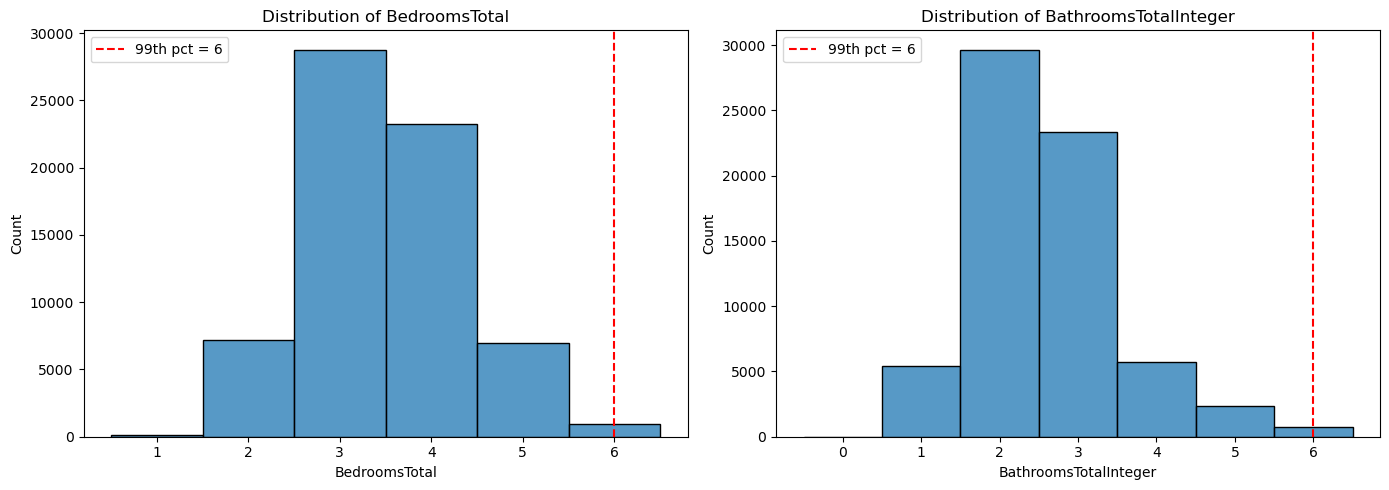

BedroomsTotal       99th pct: 6,  max: 6
BathroomsTotalInteger 99th pct: 6,  max: 6


In [21]:
# Distribution of BedroomsTotal and BathroomsTotalInteger after filtering
# to check if extreme values are removed after filtered the extreme skewed variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['BedroomsTotal', 'BathroomsTotalInteger']):
    data = CRMLSSold_data[col].dropna()
    p99 = data.quantile(0.99)
    sns.histplot(data, discrete=True, ax=ax)
    ax.axvline(p99, color='red', linestyle='--', label=f'99th pct = {p99:.0f}')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"BedroomsTotal       99th pct: {CRMLSSold_data['BedroomsTotal'].quantile(0.99):.0f},  max: {CRMLSSold_data['BedroomsTotal'].max():.0f}")
print(f"BathroomsTotalInteger 99th pct: {CRMLSSold_data['BathroomsTotalInteger'].quantile(0.99):.0f},  max: {CRMLSSold_data['BathroomsTotalInteger'].max():.0f}")

In [22]:
# updated missing percentage table after filtering
all_cols = target + all_features
missing = CRMLSSold_data[all_cols].isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing.rename('% Missing').to_frame())

,% Missing
ViewYN,9.00
PoolPrivateYN,7.63
NewConstructionYN,7.43
GarageSpaces,3.64
LotSizeSquareFeet,1.77
FireplaceYN,0.08
Latitude,0.05
Longitude,0.05
YearBuilt,0.04
ClosePrice,0.00


In [23]:
# Impute amenity flags with 'Unknown' if missing
for col in ['ViewYN', 'PoolPrivateYN', 'FireplaceYN', 'NewConstructionYN']:
    CRMLSSold_data[col] = CRMLSSold_data[col].fillna('Unknown')

# Drop rows missing any baseline feature or target, except GarageSpaces/LotSizeSquareFeet
# (postal allowed to be missing too) — those two are median-imputed later via a
# pipeline step in the baseline model instead of dropping rows
baseline_cols = target + baseline_features
strict_cols = [c for c in baseline_cols if c not in impute_later_cols]
n = len(CRMLSSold_data)
CRMLSSold_data = CRMLSSold_data.dropna(subset=strict_cols)
print(f"After dropping nulls in baseline cols: {len(CRMLSSold_data):,}  (-{n - len(CRMLSSold_data):,})")
print(f"Percentage of rows dropped: {(n - len(CRMLSSold_data)) / n:.2%}")

display(CRMLSSold_data[baseline_cols].isna().mean().mul(100).round(2).sort_values(ascending=False).rename('% Missing').to_frame())

After dropping nulls in baseline cols: 67,226  (-59)
Percentage of rows dropped: 0.09%


,% Missing
GarageSpaces,3.62
LotSizeSquareFeet,1.77
ClosePrice,0.00
LivingArea,0.00
BedroomsTotal,0.00
BathroomsTotalInteger,0.00
YearBuilt,0.00
CountyOrParish,0.00
Latitude,0.00
Longitude,0.00


In [24]:
# Save two cleaned CSVs before encoding

# 1. Full feature set (for tree models and feature engineering — includes lat/long/postal)
full_save_cols = ['CloseDate'] + target + all_features
CRMLSSold_data[full_save_cols].to_csv('data/cleaned_CRMLSSOLD_all_features.csv', index=False)
print(f"Saved all-features CSV:      {CRMLSSold_data[full_save_cols].shape[0]:,} rows, {CRMLSSold_data[full_save_cols].shape[1]} columns")

# 2. Baseline feature set (for linear regression — county + lat/long, no postal)
baseline_save_cols = ['CloseDate'] + baseline_cols
CRMLSSold_data[baseline_save_cols].to_csv('data/cleaned_CRMLSSOLD_baseline.csv', index=False)
print(f"Saved baseline features CSV: {CRMLSSold_data[baseline_save_cols].shape[0]:,} rows, {CRMLSSold_data[baseline_save_cols].shape[1]} columns")

Saved all-features CSV:      67,226 rows, 17 columns
Saved baseline features CSV: 67,226 rows, 16 columns


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

CRMLSSold_data['LogClosePrice'] = np.log(CRMLSSold_data['ClosePrice'])
CRMLSSold_data['LogLivingArea'] = np.log(CRMLSSold_data['LivingArea'])

cat_cols = ['CountyOrParish', 'ViewYN', 'PoolPrivateYN', 'FireplaceYN', 'NewConstructionYN', 'HasAssociationFee']
CRMLSSold_data = pd.get_dummies(CRMLSSold_data, columns=cat_cols, dtype=int)

CRMLSSold_data['CloseMonth'] = CRMLSSold_data['CloseDate'].dt.to_period('M')

log_features = ['LogLivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                'YearBuilt', 'GarageSpaces', 'LotSizeSquareFeet']
encoded_cols = [c for c in CRMLSSold_data.columns
                if c.startswith(('CountyOrParish_', 'ViewYN_', 'PoolPrivateYN_', 'FireplaceYN_',
                                  'NewConstructionYN_', 'HasAssociationFee_'))]
feature_cols = log_features + encoded_cols

scale_cols = ['LogLivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
              'YearBuilt', 'GarageSpaces', 'LotSizeSquareFeet']
# GarageSpaces/LotSizeSquareFeet still carry NaNs at this point — median-impute
# them (fit on train only) before scaling
impute_cols = ['GarageSpaces', 'LotSizeSquareFeet']

def make_train_test_split(df, feature_cols, scale_cols, training_months=None):
    """
    Split df into train/test by time.

    test  = the most recent month in the data
    train = the X months immediately before the test month
            if training_months is None, use all available preceding months
    """
    test_month  = df['CloseMonth'].max()
    train_start = test_month - training_months if training_months else df['CloseMonth'].min()

    train = df[(df['CloseMonth'] >= train_start) & (df['CloseMonth'] < test_month)].copy()
    test  = df[df['CloseMonth'] == test_month].copy()

    imputer = SimpleImputer(strategy='median')
    train[impute_cols] = imputer.fit_transform(train[impute_cols])
    test[impute_cols]  = imputer.transform(test[impute_cols])

    scaler = StandardScaler()
    train[scale_cols] = scaler.fit_transform(train[scale_cols])
    test[scale_cols]  = scaler.transform(test[scale_cols])

    X_train = train[feature_cols]
    y_train = train['LogClosePrice']
    X_test  = test[feature_cols]
    y_test  = test['LogClosePrice']

    print(f"Test month:  {test_month}")
    print(f"Train range: {train['CloseMonth'].min()} to {train['CloseMonth'].max()}  ({train['CloseMonth'].nunique()} months)")
    print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

    return X_train, y_train, X_test, y_test, scaler


# Use all available months for training (tunable — change training_months=N to experiment)
X_train, y_train, X_test, y_test, scaler = make_train_test_split(
    CRMLSSold_data, feature_cols, scale_cols, training_months=None
)

Test month:  2026-05
Train range: 2025-11 to 2026-04  (6 months)
X_train: (55890, 79)  |  X_test: (11336, 79)


In [26]:
# sample of the training data
display(X_train.head())

,LogLivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,GarageSpaces,LotSizeSquareFeet,CountyOrParish_Alameda,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,...,PoolPrivateYN_Unknown,FireplaceYN_False,FireplaceYN_True,FireplaceYN_Unknown,NewConstructionYN_False,NewConstructionYN_True,NewConstructionYN_Unknown,HasAssociationFee_False,HasAssociationFee_True,HasAssociationFee_Unknown
0,-1.521092,-0.549017,-0.606585,-0.555690,0.001085,-0.288644,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
1,-1.275745,-0.549017,-1.654724,-0.993301,0.001085,0.194712,0,0,0,0,...,1,0,1,0,1,0,0,0,0,1
2,-0.341731,0.591842,0.441553,0.064260,0.001085,-0.312312,0,0,0,0,...,0,0,1,0,0,0,1,1,0,0
3,1.143460,1.732701,0.441553,0.866549,0.440365,-0.313393,0,0,0,0,...,0,0,1,0,0,0,1,0,1,0
4,-0.174409,-0.549017,-0.606585,-0.956834,0.440365,-0.111541,0,0,0,0,...,0,0,1,0,1,0,0,1,0,0
